# 专题：Triton 原理与编程模型

这份 notebook 的目标不是把 Triton 教成“又一个新语法”，而是先把更关键的一件事讲清楚：

> **Triton 到底在解决什么问题，为什么很多人会用它来写自定义高性能 kernel？**

这份材料按下面的顺序展开：

1. 先讲 Triton 在整个系统栈里的位置。
2. 再讲 Triton 最核心的编程模型：`blocked program`。
3. 用 `vector add` 讲 `program_id / arange / load / store / mask`。
4. 用 `fused softmax` 讲为什么 Triton 特别适合做融合。
5. 用 `matmul` 讲 tiling、pointer arithmetic 和 `tl.dot`。
6. 最后再讲 autotune、什么时候该用 Triton、什么时候不该用。

## 本节课学习目标

1. 理解 Triton 是什么，以及它和 PyTorch / CUDA 的关系。
2. 建立 `program instance`、`tile`、`mask` 这些核心直觉。
3. 理解 Triton 为什么特别适合写 `fused` 算子。
4. 看懂 Triton 代码时最应该抓哪几个关键点。
5. 能把 `vector add / softmax / matmul` 三个例子串成一条线。

## 先说清楚：什么是算子

在深度学习和系统实现里，**算子** 可以先理解成：

> **对数据做一次明确计算的功能单元。**

常见例子有：

- `add`
- `matmul`
- `conv`
- `relu`
- `softmax`
- `layernorm`

一个更实用的层次关系是：

- **模型**：完整网络
- **层**：模型里的一个模块
- **算子**：层内部更底层的一次具体计算

所以后面讲 Triton 时，要一直记住这句对应关系：

> **算子说的是“做什么”，Triton 关心的是“这个算子怎么写成高性能 kernel”。**

## 主要参考的官方资料

这份 notebook 主要参考以下官方资料与原始项目：

- Triton 文档首页：<https://triton-lang.org/main/index>
- Programming Guide - Introduction：<https://triton-lang.org/main/programming-guide/chapter-1/introduction.html>
- Vector Addition tutorial：<https://triton-lang.org/main/getting-started/tutorials/01-vector-add.html>
- Fused Softmax tutorial：<https://triton-lang.org/main/getting-started/tutorials/02-fused-softmax.html>
- Matrix Multiplication tutorial：<https://triton-lang.org/main/getting-started/tutorials/03-matrix-multiplication.html>
- Triton GitHub 仓库：<https://github.com/triton-lang/triton>

课堂里的讲法和图示做了重新组织，重点是把原理讲顺，而不是照着官方教程逐行念代码。

In [1]:
# ------------------------------
# 这段代码做什么：
# 1. 导入这份 notebook 会用到的库
# 2. 检查当前环境是否具备 Triton / CUDA
# 3. 如果没有，也能运行“原理讲解 + CPU 模拟”部分
# ------------------------------
import importlib.util
import math
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

HAS_TRITON = importlib.util.find_spec("triton") is not None
HAS_CUDA = torch.cuda.is_available()

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def benchmark(fn, *args, repeats=3, **kwargs):
    best = float("inf")
    out = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        out = fn(*args, **kwargs)
        dt = time.perf_counter() - t0
        best = min(best, dt)
    return out, best


print("torch version:", torch.__version__)
print("Triton installed:", HAS_TRITON)
print("CUDA available:", HAS_CUDA)
if not (HAS_TRITON and HAS_CUDA):
    print("当前环境不具备 Triton + CUDA；本 notebook 的 CPU 模拟部分可直接运行，真正 Triton 运行单元会自动跳过。")

torch version: 2.10.0
Triton installed: False
CUDA available: False
当前环境不具备 Triton + CUDA；本 notebook 的 CPU 模拟部分可直接运行，真正 Triton 运行单元会自动跳过。


# Part 1. Triton 到底是什么

官方文档把 Triton 定义为：

> **a language and compiler for parallel programming**

可以把它翻成更适合课堂的说法：

> **Triton 是一个用 Python 风格写 GPU kernel 的语言和编译器。**

这里有两个关键词必须同时记住：

1. **语言**：因为你真的在写一种有自己原语和编程模型的 kernel DSL。
2. **编译器**：因为你写出来的不只是 Python 解释执行，而是会被编译成底层设备代码。

## Triton 在哪里

<img src="images/lesson_triton_intro/triton_positioning.png" width="980">

Triton 最适合解决的，不是“把整个模型重写一遍”，而是这种问题：

- 现成 PyTorch 算子能跑，但不够快
- 需要把几个操作融合在一起
- 想写自定义 kernel，但直接上 CUDA 工程成本太高

所以可以把 Triton 的位置记成一句话：

> **它站在 PyTorch 和 CUDA 之间，专门面向自定义高性能算子。**

## Triton 不只是语法，它背后有编译链路

<img src="images/lesson_triton_intro/compiler_pipeline.png" width="980">

这张图最重要的意思是：

- 前端写的是 Python 风格 kernel
- 中间会经过 Triton IR / MLIR / LLVM 这一类编译阶段
- 最后才变成设备真正执行的代码

所以 Triton 的威力不只是“写起来像 Python”，更是因为：

> **编译器会帮你把 blocked algorithm 变成真正适合 GPU 执行的低层代码。**

## 为什么会有人觉得 Triton 比 CUDA 更好教

因为对第一次接触高性能 kernel 的人来说，最难的往往不是“算子公式”，而是：

- 线程怎么分工
- 数据怎么切块
- 边界怎么处理
- 哪些中间结果值得保留在更快的存储里

Triton 的好处是：它把这些问题保留了，但把很多底层样板收掉了。  
这让课堂更容易把注意力放在 **计算模式** 上，而不是被 API 细节冲散。

# Part 2. Triton 最核心的编程模型

官方 Programming Guide 里有一个非常重要的对比：

- CUDA 更像：**scalar program, blocked threads**
- Triton 更像：**blocked program, scalar threads**

翻成通俗的话，就是：

> **CUDA 常常让人先从“很多线程”开始想；Triton 更鼓励先从“一个程序实例处理一小块数据”开始想。**

## CUDA 和 Triton 的心智模型差别

<img src="images/lesson_triton_intro/cuda_vs_triton.png" width="980">

这里最容易卡住的点是：  
Triton 里经常不是先想“一个线程处理一个标量”，而是先想：

- 一个 `program instance`
- 负责一个 tile / block
- 在这个 block 里做向量化 load、compute、store

这个想法一旦建立起来，后面的 `tl.arange`、`tl.load`、`mask` 就好懂很多。

### 一个很重要的课堂提问点

可以先问一句：

> 如果我要做一个长度为 `N` 的向量加法，Triton 里最自然的分工方式是什么？

最通俗的答案是：

- 不是一个线程算一个元素开始想
- 而是先定一个 `BLOCK_SIZE`
- 然后每个 `program instance` 处理一整段连续元素

# Part 3. 第一个例子：vector add

这是 Triton 官方教程的第一个例子，也是最适合课堂起步的例子。  
因为它几乎可以把 Triton 的几个基本原语一次讲清：

- `tl.program_id`
- `tl.arange`
- `tl.load`
- `tl.store`
- `mask`

## 先看图，不急着看代码

<img src="images/lesson_triton_intro/vector_add_program.png" width="980">

这张图要说明的是：

- `pid=0` 处理前一段
- `pid=1` 处理下一段
- 每个 `program instance` 负责一整块连续 offsets

所以 Triton 代码最常见的第一步，就是：

> **先算出“我这一块要处理哪些位置”。**

In [2]:
# ------------------------------
# 这段代码做什么：
# 1. 用 CPU 模拟 Triton 里的 vector add 分工方式
# 2. 直接把 pid、offsets、mask 打印出来
# 3. 让 program instance 的含义变得非常具体
# ------------------------------
def simulate_triton_vector_blocks(n_elements, block_size):
    n_programs = math.ceil(n_elements / block_size)
    rows = []
    for pid in range(n_programs):
        offsets = pid * block_size + np.arange(block_size)
        mask = offsets < n_elements
        rows.append((pid, offsets, mask))
    return rows


rows = simulate_triton_vector_blocks(n_elements=18, block_size=8)
for pid, offsets, mask in rows:
    print(f"pid={pid}")
    print("offsets =", offsets)
    print("mask    =", mask)
    print()

pid=0
offsets = [0 1 2 3 4 5 6 7]
mask    = [ True  True  True  True  True  True  True  True]

pid=1
offsets = [ 8  9 10 11 12 13 14 15]
mask    = [ True  True  True  True  True  True  True  True]

pid=2
offsets = [16 17 18 19 20 21 22 23]
mask    = [ True  True False False False False False False]



### 这格代码最应该讲哪一句

> **`pid` 决定“我是哪一块”，`offsets` 决定“我这一块里有哪些位置”，`mask` 决定“最后一块哪些位置是真实有效的”。**

这句话讲顺以后，再看 Triton 代码就会顺很多。

## 对应的 Triton kernel 骨架

```python
@triton.jit
def add_kernel(x_ptr, y_ptr, out_ptr, n, BLOCK_SIZE: tl.constexpr):
    pid = tl.program_id(axis=0)
    offsets = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
    mask = offsets < n
    x = tl.load(x_ptr + offsets, mask=mask, other=0.0)
    y = tl.load(y_ptr + offsets, mask=mask, other=0.0)
    tl.store(out_ptr + offsets, x + y, mask=mask)
```

逐句翻译：

- `tl.program_id(axis=0)`：我现在是第几个 program instance
- `tl.arange(0, BLOCK_SIZE)`：我这一块内部的局部下标
- `tl.load(..., mask=mask)`：只读有效位置，越界位置用默认值补上
- `tl.store(..., mask=mask)`：只把有效位置写回去

In [3]:
# ------------------------------
# 这段代码做什么：
# 1. 用 NumPy 写一个“按 block 处理”的向量加法
# 2. 模拟 Triton kernel 的工作方式，而不是直接整向量一把算完
# ------------------------------
def vector_add_blocked(x, y, block_size):
    n = len(x)
    out = np.empty_like(x)
    n_programs = math.ceil(n / block_size)
    for pid in range(n_programs):
        offsets = pid * block_size + np.arange(block_size)
        mask = offsets < n
        valid = offsets[mask]
        out[valid] = x[valid] + y[valid]
    return out


x = np.arange(18, dtype=np.float32)
y = 100 + np.arange(18, dtype=np.float32)
out = vector_add_blocked(x, y, block_size=8)
print("x   =", x)
print("y   =", y)
print("out =", out)

x   = [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.]
y   = [100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112. 113.
 114. 115. 116. 117.]
out = [100. 102. 104. 106. 108. 110. 112. 114. 116. 118. 120. 122. 124. 126.
 128. 130. 132. 134.]


## 这时可以加一个提问

> 为什么 Triton 里几乎总是会出现 `mask`？

通俗答案是：

- block 大小通常是一个固定的调优参数
- 数据长度未必刚好是 block 的整数倍
- 所以最后一个 program instance 往往会“多算出几个位置”
- `mask` 就是用来挡住这些越界访存

# Part 4. Triton 为什么特别适合讲 fusion

Triton 很受欢迎的一个核心原因，不只是“能写 kernel”，而是：

> **它很适合把几个本来分散的小操作，融合成一个 kernel。**

这在深度学习里非常重要，因为很多时候瓶颈不在算术本身，而在：

- 数据反复从显存读进来
- 中间结果反复写回去
- 小算子很多，launch 也很多

## softmax 的融合直觉

<img src="images/lesson_triton_intro/fused_softmax.png" width="980">

官方 softmax 教程的核心思想可以讲得很简单：

- 如果按“很多独立小操作”去做 softmax，会产生大量中间读写
- 如果一整行能放进合适的 on-chip 工作区，那就可以在一个 kernel 里把这行做完

所以 Triton 的一个教学亮点，不是“写一个更复杂的 softmax”，而是：

> **让人看清：kernel fusion 为什么值钱。**

{'naive_total': 8392704, 'fused_total': 2097152}


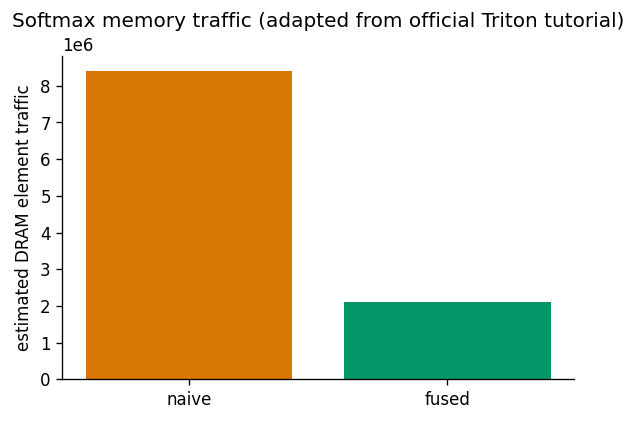

In [4]:
# ------------------------------
# 这段代码做什么：
# 1. 用官方 softmax 教程里的读写量估算公式
# 2. 对比 naive 分解和 fused kernel 的显存访问量
# ------------------------------
def softmax_io_counts(M, N):
    naive_reads = 5 * M * N + 2 * M
    naive_writes = 3 * M * N + 2 * M
    fused_reads = M * N
    fused_writes = M * N
    return {
        "naive_total": naive_reads + naive_writes,
        "fused_total": fused_reads + fused_writes,
    }


M, N = 1024, 1024
counts = softmax_io_counts(M, N)
print(counts)

labels = ["naive", "fused"]
values = [counts["naive_total"], counts["fused_total"]]

plt.figure(figsize=(5.5, 3.5))
plt.bar(labels, values, color=["#D97706", "#059669"])
plt.ylabel("estimated DRAM element traffic")
plt.title("Softmax memory traffic (adapted from official Triton tutorial)")
plt.show()

### 这里要讲透的不是公式，而是结论

结论只有一句：

> **如果一个操作可以在 kernel 里就地连着做完，就尽量别拆成很多次显存往返。**

这也是 Triton 在课堂上特别好讲的一点，因为它非常容易把“融合”的价值讲得具体。

## 一个简化版 softmax kernel 骨架

```python
@triton.jit
def softmax_kernel(out_ptr, x_ptr, row_stride, n_rows, n_cols, BLOCK_SIZE: tl.constexpr):
    row_id = tl.program_id(0)
    cols = tl.arange(0, BLOCK_SIZE)
    mask = cols < n_cols
    row_ptr = x_ptr + row_id * row_stride + cols
    x = tl.load(row_ptr, mask=mask, other=-float("inf"))
    x = x - tl.max(x, axis=0)
    num = tl.exp(x)
    den = tl.sum(num, axis=0)
    y = num / den
    tl.store(out_ptr + row_id * row_stride + cols, y, mask=mask)
```

这段代码比 vector add 多出来的本质只有两个：

1. 一个 `program instance` 不只是做逐元素加法，而是处理整行
2. 这一行里的多个步骤，在同一个 kernel 里被融合了

# Part 5. Triton 里最重要的第二个大例子：matmul

如果说 vector add 用来教入门，softmax 用来教 fusion，  
那 matmul 最适合拿来讲：

- blocked algorithm
- pointer arithmetic
- tiling
- `tl.dot`
- autotune

## matmul 的 blocked 思路

<img src="images/lesson_triton_intro/matmul_tiling.png" width="980">

官方 matmul 教程里最核心的那句话可以翻成：

> **每个 Triton program instance 负责输出矩阵 `C` 的一个 tile。**

这句话非常重要，因为它几乎决定了后面所有代码怎么写。

In [5]:
# ------------------------------
# 这段代码做什么：
# 1. 用 CPU 模拟 matmul 里“一个 program instance 负责一个 C tile”
# 2. 把输出矩阵分块的方式直接可视化
# ------------------------------
def tile_assignments(M, N, BM, BN):
    assigns = []
    for pid_m in range(math.ceil(M / BM)):
        for pid_n in range(math.ceil(N / BN)):
            row0 = pid_m * BM
            row1 = min(row0 + BM, M)
            col0 = pid_n * BN
            col1 = min(col0 + BN, N)
            assigns.append((pid_m, pid_n, row0, row1, col0, col1))
    return assigns


assigns = tile_assignments(M=10, N=12, BM=4, BN=5)
for item in assigns:
    print(item)

(0, 0, 0, 4, 0, 5)
(0, 1, 0, 4, 5, 10)
(0, 2, 0, 4, 10, 12)
(1, 0, 4, 8, 0, 5)
(1, 1, 4, 8, 5, 10)
(1, 2, 4, 8, 10, 12)
(2, 0, 8, 10, 0, 5)
(2, 1, 8, 10, 5, 10)
(2, 2, 8, 10, 10, 12)


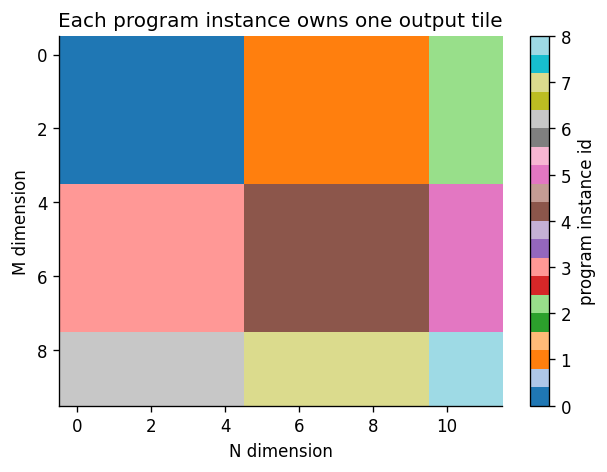

In [6]:
# ------------------------------
# 这段代码做什么：
# 1. 把上面的 tile 分配画出来
# 2. 让“一个 program instance 负责一个输出块”变成可见图像
# ------------------------------
M, N = 10, 12
BM, BN = 4, 5
canvas = np.full((M, N), -1, dtype=int)

pid = 0
for pid_m in range(math.ceil(M / BM)):
    for pid_n in range(math.ceil(N / BN)):
        r0 = pid_m * BM
        r1 = min(r0 + BM, M)
        c0 = pid_n * BN
        c1 = min(c0 + BN, N)
        canvas[r0:r1, c0:c1] = pid
        pid += 1

plt.figure(figsize=(6, 4))
plt.imshow(canvas, cmap="tab20")
plt.colorbar(label="program instance id")
plt.title("Each program instance owns one output tile")
plt.xlabel("N dimension")
plt.ylabel("M dimension")
plt.show()

### 这两格图和代码在说什么

它们要传达的不是“矩阵乘法公式”，而是更底层的一件事：

> **Triton 里并不是让很多 program instance 去抢着算同一个输出矩阵位置，而是先把输出矩阵切块，每个实例管一块。**

这个思路一旦清楚，pointer arithmetic 才有落点，因为你知道自己到底在读哪块 A、哪块 B、写哪块 C。

## 一个简化版 Triton matmul 骨架

```python
@triton.jit
def matmul_kernel(a_ptr, b_ptr, c_ptr,
                  M, N, K,
                  stride_am, stride_ak,
                  stride_bk, stride_bn,
                  stride_cm, stride_cn,
                  BLOCK_M: tl.constexpr,
                  BLOCK_N: tl.constexpr,
                  BLOCK_K: tl.constexpr):
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)

    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    offs_k = tl.arange(0, BLOCK_K)

    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    for k0 in range(0, K, BLOCK_K):
        a = tl.load(...)
        b = tl.load(...)
        acc += tl.dot(a, b)
    tl.store(...)
```

这段代码课堂上最该看的不是省略号，而是结构：

- 先定位自己负责的 `(pid_m, pid_n)` 输出块
- 再构造这个块对应的行列 offsets
- 然后沿着 `K` 方向一块块累加

# Part 6. Triton 为什么经常和 autotune 一起出现

Triton 里经常能看到这些参数：

- `BLOCK_SIZE`
- `BLOCK_M / BLOCK_N / BLOCK_K`
- `num_warps`
- `num_stages`

初次接触时最容易误解成：

> “是不是数学变了？”

其实不是。更准确的理解是：

> **数学没变，变的是切块方式和执行配置。**

tile= 8, time=0.007011s
tile=16, time=0.002063s
tile=32, time=0.000289s
tile=64, time=0.000051s


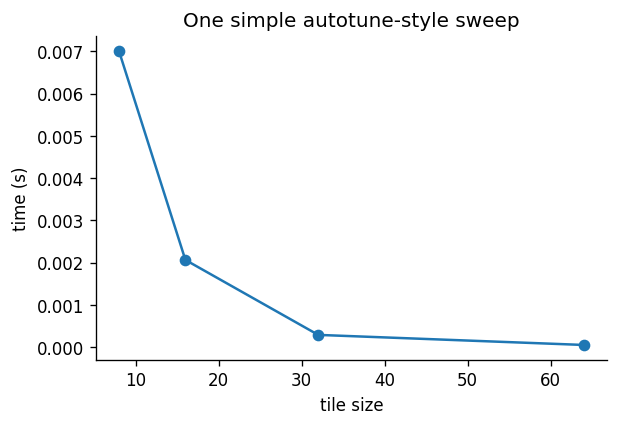

In [7]:
# ------------------------------
# 这段代码做什么：
# 1. 用 CPU 版本的 blocked matmul 做一个极简 autotune 演示
# 2. 让“不同 block size 会影响性能”这件事变得可见
# ------------------------------
def matmul_tiled(A, B, tile):
    m, k = A.shape
    k2, n = B.shape
    assert k == k2
    C = np.zeros((m, n), dtype=np.float32)
    for i0 in range(0, m, tile):
        for j0 in range(0, n, tile):
            for k0 in range(0, k, tile):
                i1 = min(i0 + tile, m)
                j1 = min(j0 + tile, n)
                k1 = min(k0 + tile, k)
                C[i0:i1, j0:j1] += A[i0:i1, k0:k1] @ B[k0:k1, j0:j1]
    return C


A = np.random.randn(128, 128).astype(np.float32)
B = np.random.randn(128, 128).astype(np.float32)
tile_sizes = [8, 16, 32, 64]
times = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    for tile in tile_sizes:
        _, t = benchmark(matmul_tiled, A, B, repeats=3, tile=tile)
        times.append(t)

for tile, t in zip(tile_sizes, times):
    print(f"tile={tile:>2d}, time={t:.6f}s")

plt.figure(figsize=(5.5, 3.5))
plt.plot(tile_sizes, times, marker="o")
plt.xlabel("tile size")
plt.ylabel("time (s)")
plt.title("One simple autotune-style sweep")
plt.show()

### 这一格为什么很重要

它要说明的是：

- Triton 里常见的 meta-parameters 并不是装饰
- 它们通常决定了切块大小、并行度、缓存利用方式
- 不同硬件、不同输入规模，最优参数经常不同

所以 Triton 经常会把“同一个 kernel 的多个配置”拿去 benchmark，然后选更合适的那个。  
这就是课堂里讲 `autotune` 最通俗的方式。

# Part 7. 如果当前环境支持 Triton，最小例子可以怎么跑

当前机器如果没有 Triton 或 CUDA，这一部分会自动跳过。  
这一格的意义主要是：

- 把前面讲过的原理和真正的 Triton 代码接起来
- 让有 GPU 环境时，这份 notebook 也能继续往下用

In [8]:
# ------------------------------
# 这段代码做什么：
# 1. 如果当前环境支持 Triton + CUDA，就尝试跑一个最小 vector add kernel
# 2. 如果不支持，就直接提示跳过
# ------------------------------
if HAS_TRITON and HAS_CUDA:
    import triton
    import triton.language as tl

    @triton.jit
    def add_kernel(x_ptr, y_ptr, out_ptr, n_elements, BLOCK_SIZE: tl.constexpr):
        pid = tl.program_id(axis=0)
        offsets = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
        mask = offsets < n_elements
        x = tl.load(x_ptr + offsets, mask=mask, other=0.0)
        y = tl.load(y_ptr + offsets, mask=mask, other=0.0)
        tl.store(out_ptr + offsets, x + y, mask=mask)

    def triton_add(x, y):
        out = torch.empty_like(x)
        n = out.numel()
        grid = lambda meta: (triton.cdiv(n, meta["BLOCK_SIZE"]),)
        add_kernel[grid](x, y, out, n, BLOCK_SIZE=1024)
        return out

    x = torch.randn(4096, device="cuda", dtype=torch.float32)
    y = torch.randn(4096, device="cuda", dtype=torch.float32)
    out_triton = triton_add(x, y)
    out_torch = x + y
    print("max abs diff =", torch.max(torch.abs(out_triton - out_torch)).item())
else:
    print("跳过 Triton 实际运行：当前环境没有 Triton + CUDA。")

跳过 Triton 实际运行：当前环境没有 Triton + CUDA。


# Part 8. 最后怎么收束

到这里，Triton 不应该再被讲成“一个神秘的新框架”，而应该被讲成：

> **一种用 blocked algorithm 写自定义 GPU kernel 的方式。**

最适合最后收束成下面这几句：

1. Triton 的核心不是语法，而是 **一个 program instance 负责一个 tile**。
2. Triton 特别适合讲清 **mask、fusion、tiling、autotune**。
3. 看 Triton 代码时，先问“我这一块在算哪块输出”，再看 `load/store` 和 `dot/sum/max`。

In [9]:
# ------------------------------
# 这段代码做什么：
# 1. 给出课堂上可以现场追问的几个问题
# 2. 方便把这份 notebook 真正讲成互动课，而不是单向演示
# ------------------------------
questions = [
    "为什么 Triton 里经常不是先想线程，而是先想 block / tile？",
    "为什么最后一个 block 往往需要 mask？",
    "为什么 softmax 很适合拿来讲 fusion？",
    "为什么 matmul 的性能常常和 tile size 有强关系？",
    "什么场景更适合直接用现成 PyTorch 算子，而不是自己写 Triton kernel？",
]

for i, q in enumerate(questions, 1):
    print(f"{i}. {q}")

1. 为什么 Triton 里经常不是先想线程，而是先想 block / tile？
2. 为什么最后一个 block 往往需要 mask？
3. 为什么 softmax 很适合拿来讲 fusion？
4. 为什么 matmul 的性能常常和 tile size 有强关系？
5. 什么场景更适合直接用现成 PyTorch 算子，而不是自己写 Triton kernel？


## 这份 notebook 最后一句总结

> **Triton 不是让人“背更多 API”，而是让人用更清楚的 blocked 思维去写高性能 kernel。**